# Phenotype Inheritance and Trait Variation in a Dachshund × French Bulldog Cross


## 1.Introduction

For this project, I chose a topic that is personal and visually observable, but still suitable for mathematical analysis. The study is based on a real dog family made up of:

- a French Bulldog mother,
- a Dachshund father,
- a litter of 7 puppies
- and my own dog, Naya, observed both as a puppy and later as an older dog.

The project does **not** attempt to determine the true DNA genotypes of the dogs. Instead, it is a phenotype-based analysis. This means the investigation uses only visible traits observed from photographs.

A **phenotype** is any observable characteristic, such as ear shape, coat colour, body structure, or markings. Phenotypes are influenced by inherited genes, but they can also be affected by development and environment.

The aim of the project is to organise these observations into a dataset and analyse them using simple mathematical tools. In particular, I focus on two traits:

1. ear carriage
2. coat colour / markings

These traits were chosen because they are easy to observe in photographs, simple to classify, and suitable for counting, proportions, probability, and simulation.

A particularly interesting case is Naya. As a puppy, her ears were drooping, but later they became fully upright at around 5–6 months of age. This makes her a useful example of how phenotype can sometimes change during development.

## Photos of parents and dog litter

The following photographs provide the visual evidence used for the phenotype observations in this project

### 5.1 Mother (French Bulldog)
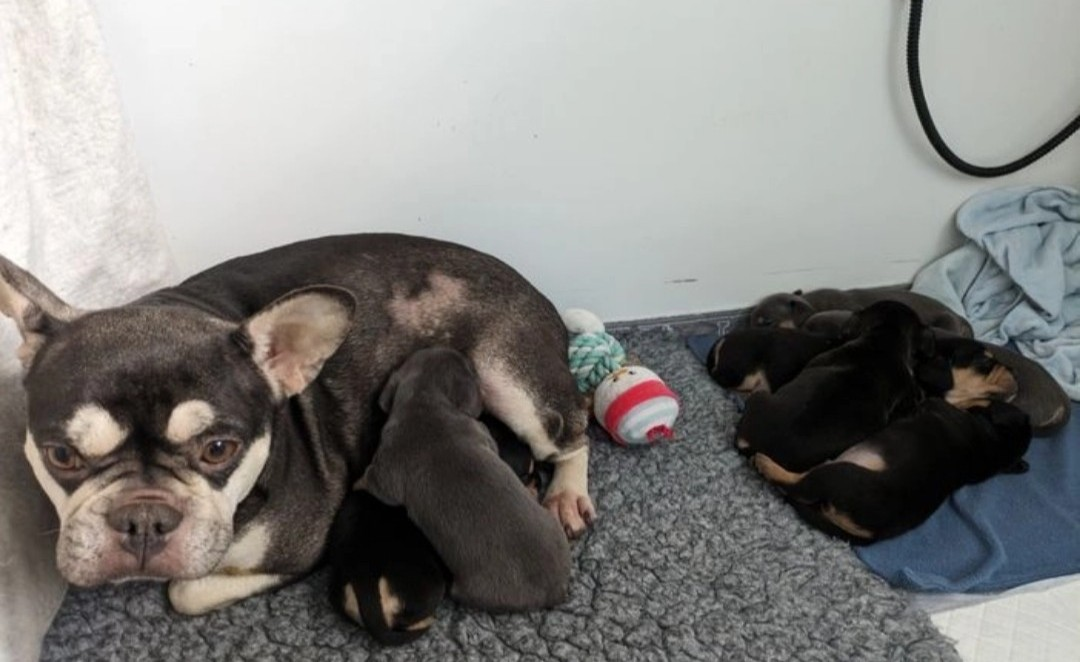

The mother has a compact body shape, a broad chest, and upright ears.

### 5.2 Father (Dachshund)
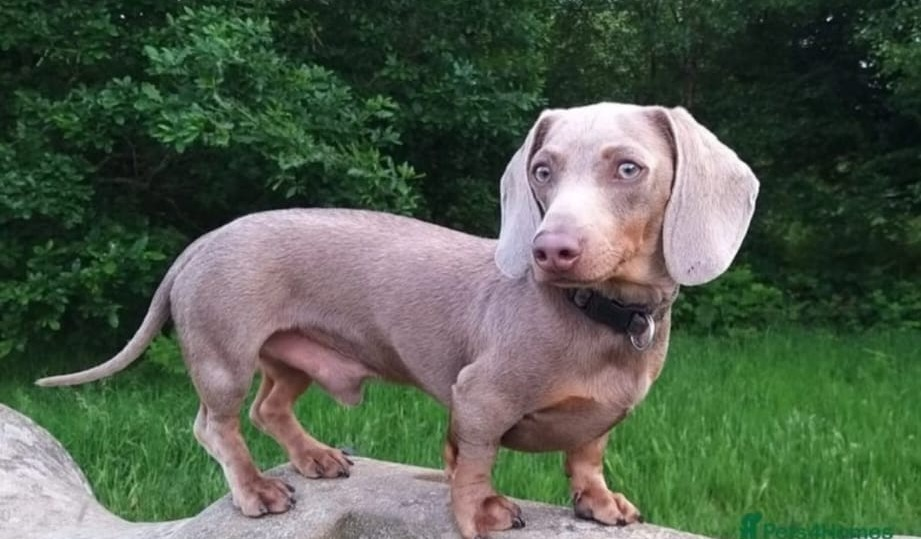

The father has a long body, short legs, and drooping ears.

### 5.3 Mother with puppy
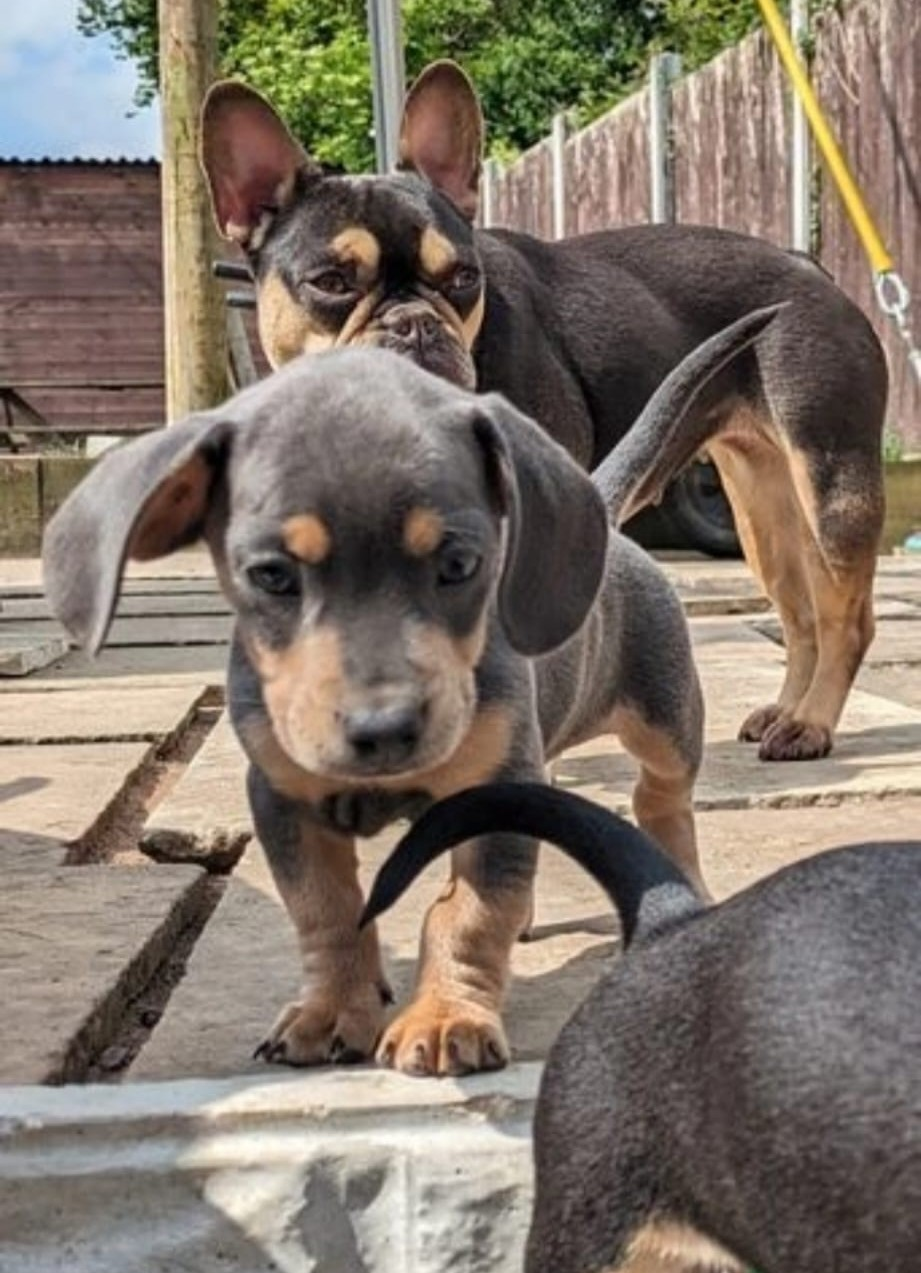

### 5.4 Puppy examples from the litter
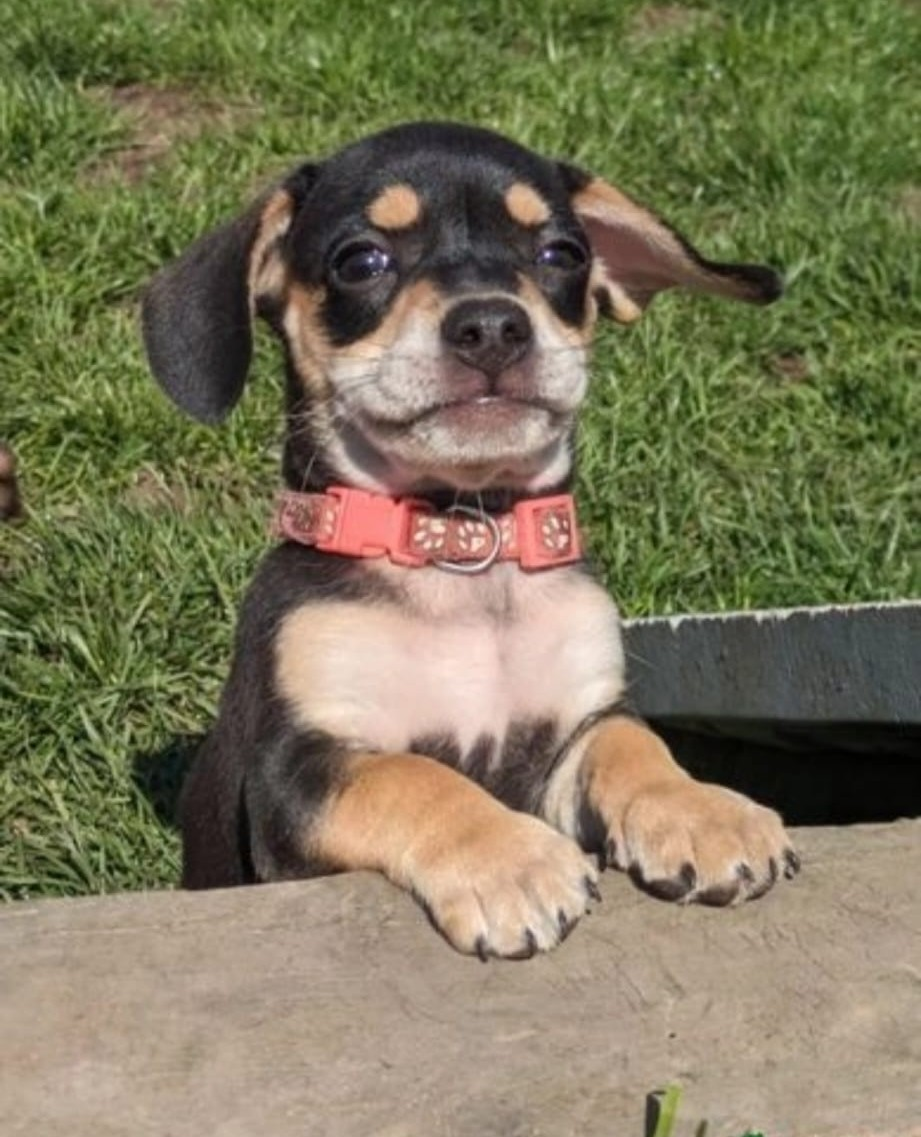

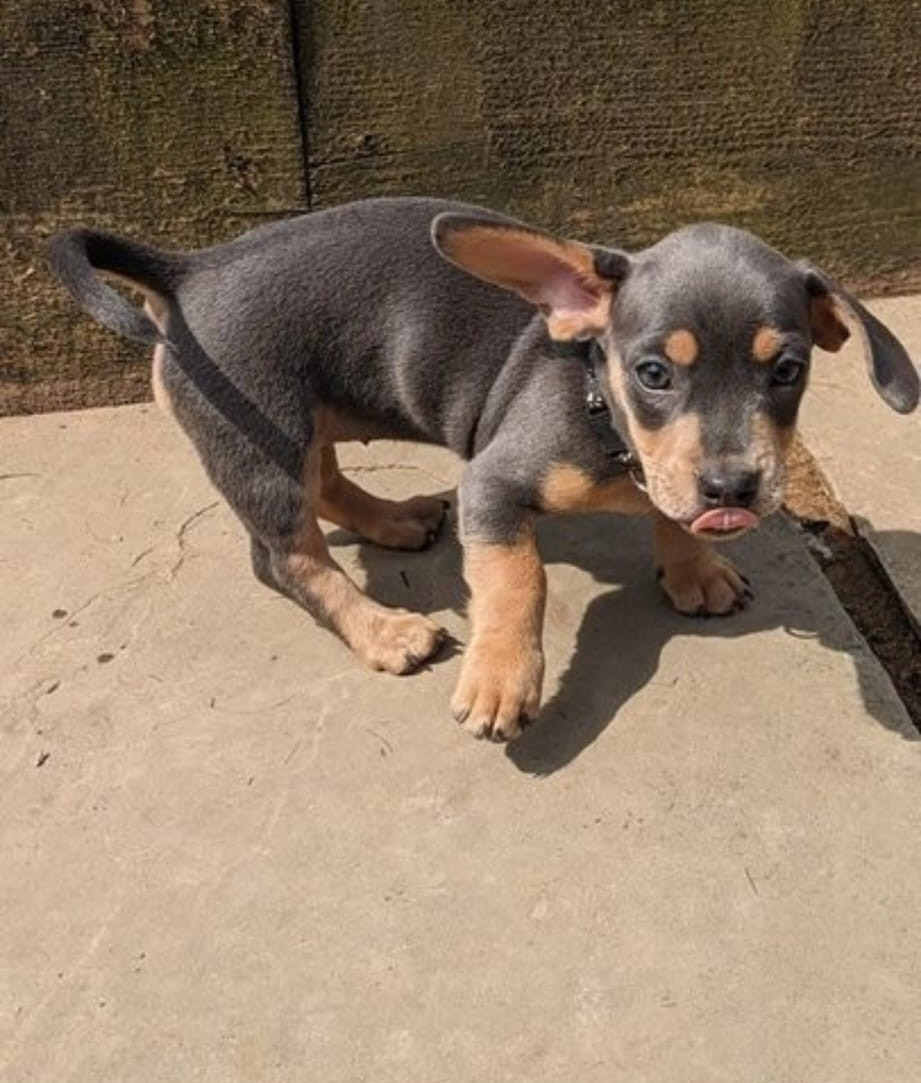

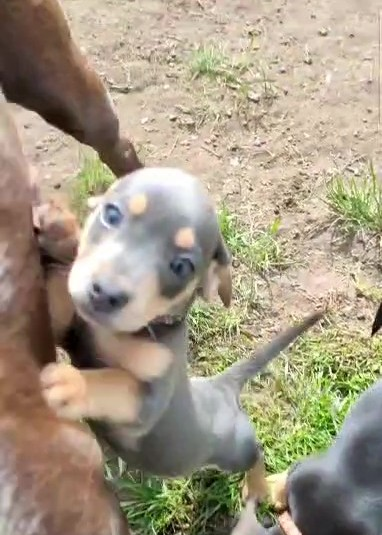

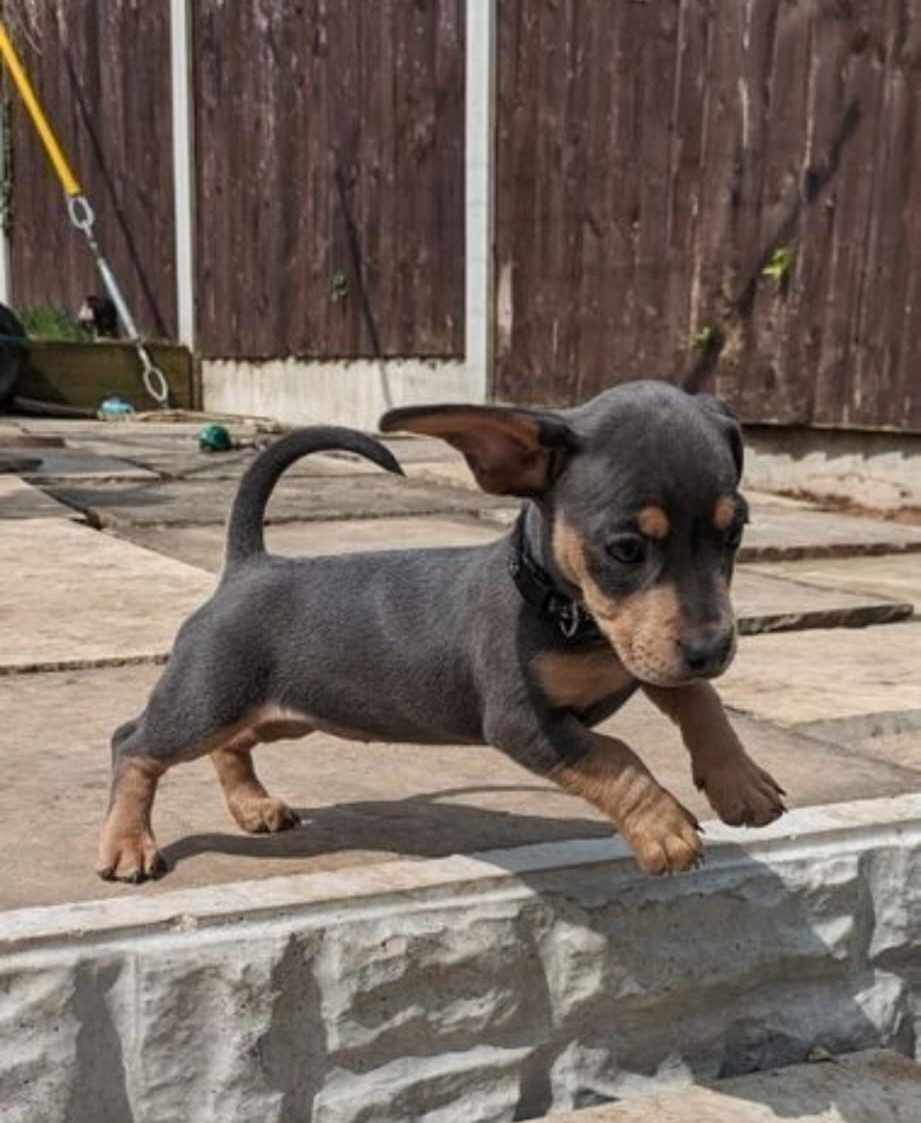

These puppy photos show the early drooping-ear stage and variation in coat colour and markings.

### 5.5 Naya as a puppy
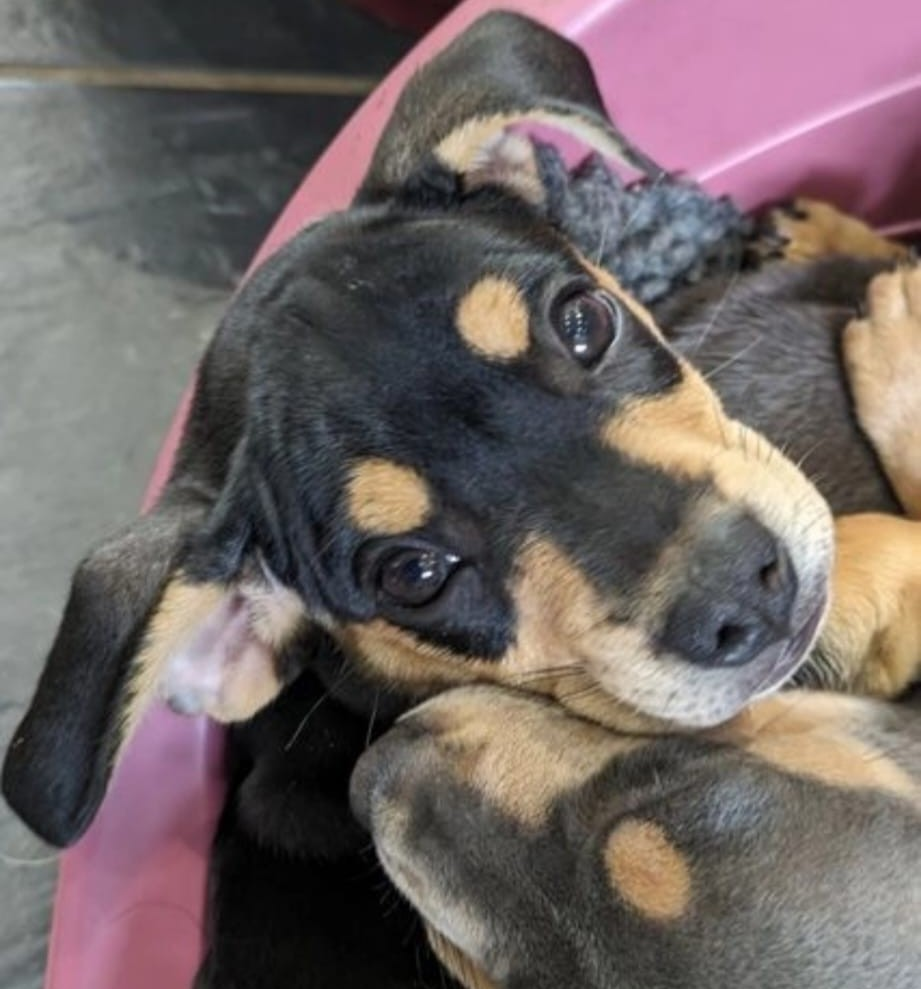

Naya is shown here at a young age with drooping ears.

### 5.6 Naya later in development
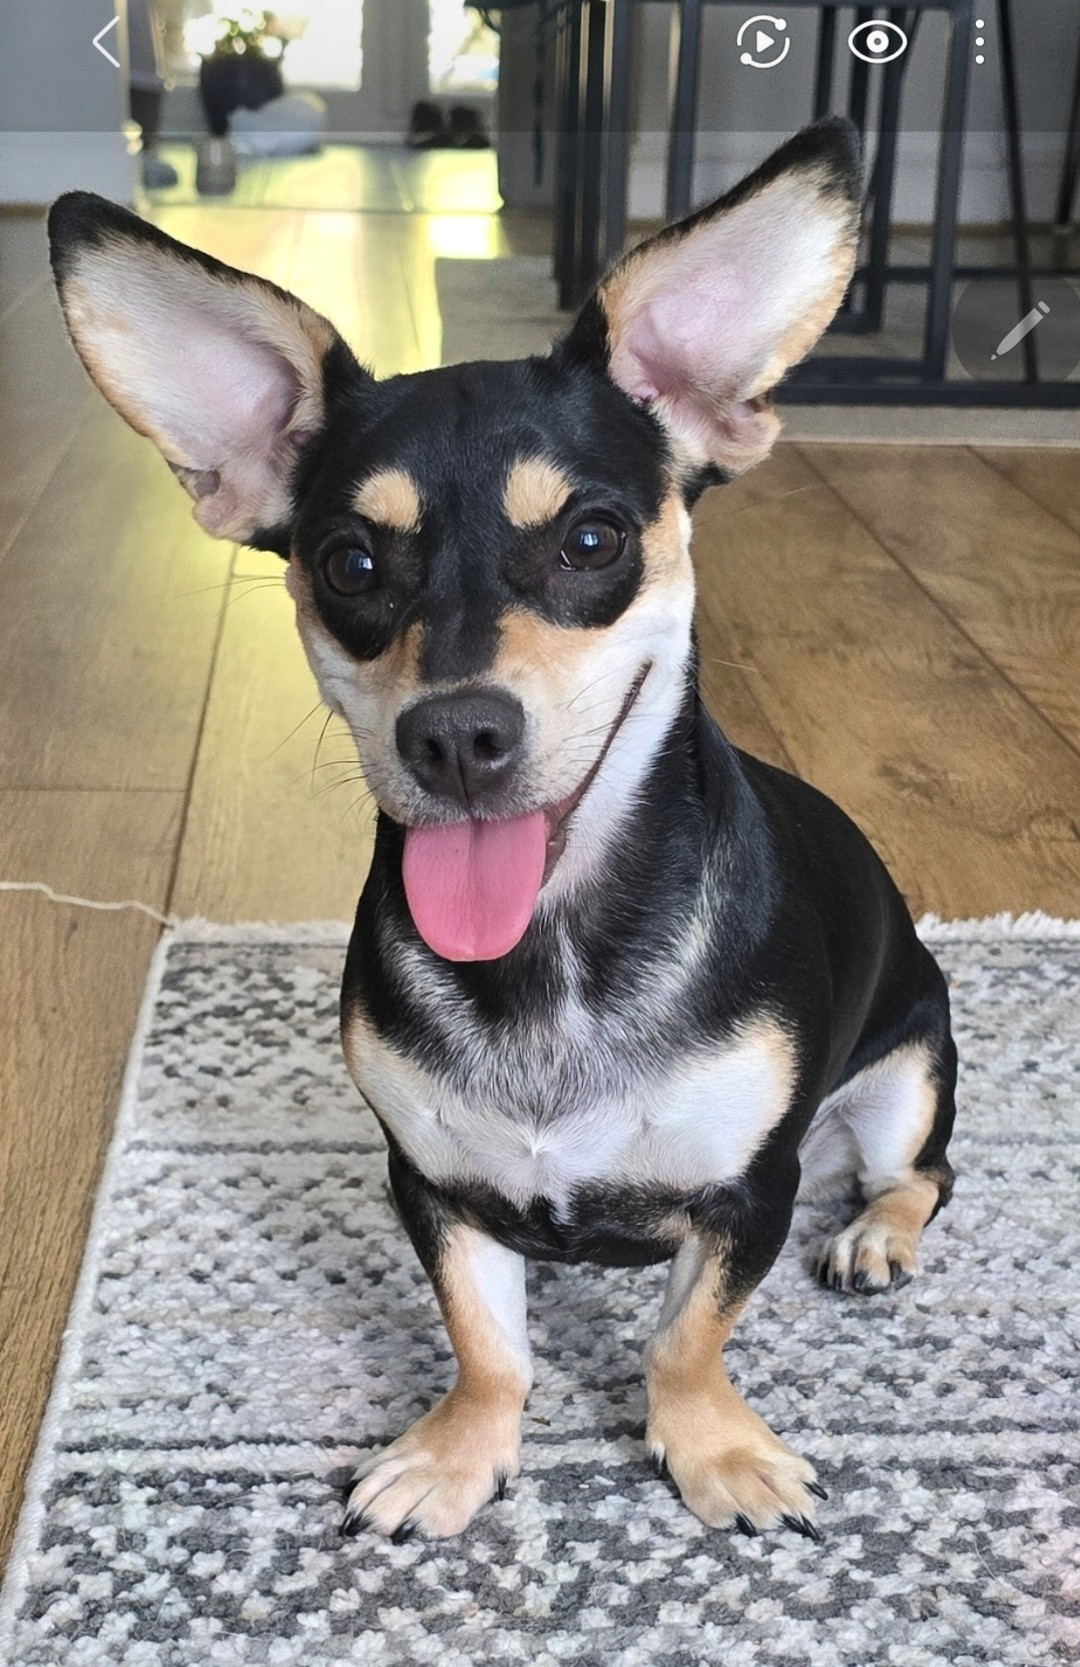

In the later image, Naya shows fully upright ears. This developmental change is one of the main observations discussed in the project.

## Observational dataset

import panda as pd

The family observations are organised into a dataset.  
The litter contains 7 puppies. The two parents are also included in the full table for reference.

### Variables

- **dog**: label for each dog
- **role**: mother, father, or puppy
- **ear_stage_puppy**: ear shape when young
- **ear_adult**: ear shape later / at adult stage
- **coat_type**: observed coat pattern
- **white_chest**: whether white on the chest is visible
- **notes**: short observation

Table 1 shows the raw observational dataset of the dogs and their traits

In [14]:
dogs = pd.DataFrame([
    {"dog": "mother", "role": "mother", "ear_stage_puppy": None, "ear_adult": "upright", "coat_type": "black_tan", "white_chest": "no", "notes": "French Bulldog mother"},
    {"dog": "father", "role": "father", "ear_stage_puppy": None, "ear_adult": "drooping", "coat_type": "lilac_tan", "white_chest": "no", "notes": "Dachshund father"},

    {"dog": "puppy_1", "role": "puppy", "ear_stage_puppy": "drooping", "ear_adult": "drooping", "coat_type": "black_tan", "white_chest": "no", "notes": "Sibling"},
    {"dog": "puppy_2", "role": "puppy", "ear_stage_puppy": "drooping", "ear_adult": "drooping", "coat_type": "black_tan", "white_chest": "no", "notes": "Sibling"},
    {"dog": "puppy_3", "role": "puppy", "ear_stage_puppy": "drooping", "ear_adult": "drooping", "coat_type": "black_tan", "white_chest": "no", "notes": "Sibling"},
    {"dog": "puppy_4", "role": "puppy", "ear_stage_puppy": "drooping", "ear_adult": "drooping", "coat_type": "black_tan", "white_chest": "no", "notes": "Sibling"},
    {"dog": "puppy_5", "role": "puppy", "ear_stage_puppy": "drooping", "ear_adult": "drooping", "coat_type": "blue_gray", "white_chest": "no", "notes": "Sibling"},
    {"dog": "puppy_6", "role": "puppy", "ear_stage_puppy": "drooping", "ear_adult": "upright", "coat_type": "blue_gray", "white_chest": "no", "notes": "Sibling with later upright ears"},
    {"dog": "puppy_7_Naya", "role": "puppy", "ear_stage_puppy": "drooping", "ear_adult": "upright", "coat_type": "black_tan_cream", "white_chest": "yes", "notes": "Naya"}
])

dogs

,dog,role,ear_stage_puppy,ear_adult,coat_type,white_chest,notes
0,mother,mother,None,upright,black_tan,no,French Bulldog mother
1,father,father,None,drooping,lilac_tan,no,Dachshund father
2,puppy_1,puppy,drooping,drooping,black_tan,no,Sibling
3,puppy_2,puppy,drooping,drooping,black_tan,no,Sibling
4,puppy_3,puppy,drooping,drooping,black_tan,no,Sibling
5,puppy_4,puppy,drooping,drooping,black_tan,no,Sibling
6,puppy_5,puppy,drooping,drooping,blue_gray,no,Sibling
7,puppy_6,puppy,drooping,upright,blue_gray,no,Sibling with later upright ears
8,puppy_7_Naya,puppy,drooping,upright,black_tan_cream,yes,Naya


Table 2 summarises how many dogs display each observed trait. The results are interpreted in the section below.

In [15]:
litter = dogs[dogs["role"] == "puppy"].copy()
litter

,dog,role,ear_stage_puppy,ear_adult,coat_type,white_chest,notes
2,puppy_1,puppy,drooping,drooping,black_tan,no,Sibling
3,puppy_2,puppy,drooping,drooping,black_tan,no,Sibling
4,puppy_3,puppy,drooping,drooping,black_tan,no,Sibling
5,puppy_4,puppy,drooping,drooping,black_tan,no,Sibling
6,puppy_5,puppy,drooping,drooping,blue_gray,no,Sibling
7,puppy_6,puppy,drooping,upright,blue_gray,no,Sibling with later upright ears
8,puppy_7_Naya,puppy,drooping,upright,black_tan_cream,yes,Naya


## Frequency tables

In [19]:
ear_counts = litter["ear_adult"].value_counts().rename_axis("ear_adult").reset_index(name="count")
coat_counts = litter["coat_type"].value_counts().rename_axis("coat_type").reset_index(name="count")
puppy_ear_counts = litter["ear_stage_puppy"].value_counts().rename_axis("ear_stage_puppy").reset_index(name="count")
white_counts = litter["white_chest"].value_counts().rename_axis("white_chest").reset_index(name="count")

print("Adult ear counts")
display(ear_counts)

print("Coat counts")
display(coat_counts)

print("Puppy-stage ear counts")
display(puppy_ear_counts)

print("White chest counts")
display(white_counts)

Adult ear counts


,ear_adult,count
0,drooping,5
1,upright,2


Coat counts


,coat_type,count
0,black_tan,4
1,blue_gray,2
2,black_tan_cream,1


Puppy-stage ear counts


,ear_stage_puppy,count
0,drooping,7


White chest counts


,white_chest,count
0,no,6
1,yes,1


### Interpretation

From the litter:

- **2 puppies** had **upright ears** at the later/adult stage
- **5 puppies** had **drooping ears** at the later/adult stage
- **1 puppy** had **black-tan-cream** colouring
- **4 puppies** had **black and tan** colouring
- **2 puppies** had **blue-gray** colouring

At the puppy stage, **all 7 puppies** were recorded as having **drooping ears**.

## Visualisations

In [26]:
import matplotlib.pyplot as plt

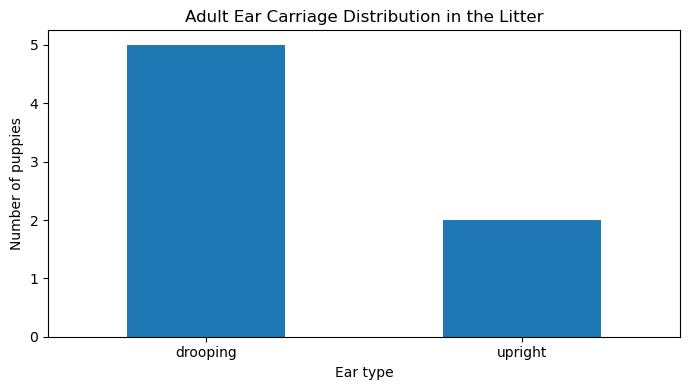

In [27]:
ear_plot = litter["ear_adult"].value_counts().sort_index()
plt.figure(figsize=(7,4))
ear_plot.plot(kind="bar")
plt.title("Adult Ear Carriage Distribution in the Litter")
plt.xlabel("Ear type")
plt.ylabel("Number of puppies")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

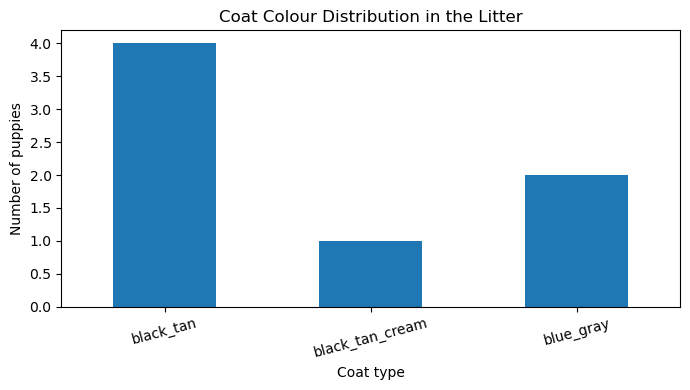

In [28]:
coat_plot = litter["coat_type"].value_counts().sort_index()
plt.figure(figsize=(7,4))
coat_plot.plot(kind="bar")
plt.title("Coat Colour Distribution in the Litter")
plt.xlabel("Coat type")
plt.ylabel("Number of puppies")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [29]:
transition_table = pd.crosstab(litter["ear_stage_puppy"], litter["ear_adult"])
transition_table

ear_adult,drooping,upright
ear_stage_puppy,,
drooping,5,2


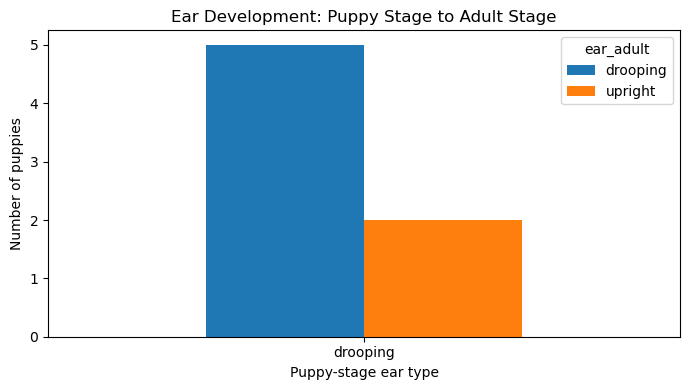

In [30]:
transition_table.plot(kind="bar", figsize=(7,4))
plt.title("Ear Development: Puppy Stage to Adult Stage")
plt.xlabel("Puppy-stage ear type")
plt.ylabel("Number of puppies")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Proportions

A proportion is calculated using

$$
p = \frac{k}{n}
$$

where:

- $k$ = number of observed cases with the trait
- $n$ = total number of puppies


In [33]:
n_puppies = len(litter)
upright_adult = (litter["ear_adult"] == "upright").sum()
black_tan_cream = (litter["coat_type"] == "black_tan_cream").sum()

p_upright = upright_adult / n_puppies
p_black_tan_cream = black_tan_cream / n_puppies

proportion_summary = pd.DataFrame({
    "trait": ["upright ears (adult)", "black-tan-cream coat"],
    "k": [upright_adult, black_tan_cream],
    "n": [n_puppies, n_puppies],
    "proportion": [p_upright, p_black_tan_cream],
    "percentage": [100 * p_upright, 100 * p_black_tan_cream]
})

proportion_summary

,trait,k,n,proportion,percentage
0,upright ears (adult),2,7,0.285714,28.571429
1,black-tan-cream coat,1,7,0.142857,14.285714


### Proportion results

For upright adult ears:

$$
p = \frac{2}{7} \approx 0.286
$$

So about 28.6% of the puppies developed upright ears.

For black-tan-cream colouring:

$$
p = \frac{1}{7} \approx 0.143
$$

So about 14.3% of the puppies showed that coat pattern.


In [36]:
import math

# Binomial probability model

To model the number of puppies with a trait in a litter, a simple approach is to use the binomial distribution:

$$
P(X = k) = inom{n}{k} p^k (1-p)^{n-k}
$$

where:

- $n$ = number of puppies
- $k$ = number of puppies with the trait
- $p$ = probability of the trait


### Example A: probability of exactly 1 black-tan-cream puppy in a litter of 7

Using $p = \frac{1}{7}$, $n = 7$, and $k = 1$:

$$
P(X=1) = \binom{7}{1}\left(\frac{1}{7}\right)^1\left(\frac{6}{7}\right)^6
$$


In [40]:
n = 7
k = 1
p = 1/7

prob_exactly_1_cream = math.comb(n, k) * (p**k) * ((1-p)**(n-k))
prob_exactly_1_cream

0.3965694566039662

### Example B: probability of exactly 2 puppies with upright adult ears

Using $p = \frac{2}{7}$, $n = 7$, and $k = 2$:

$$
P(X=2) = \binom{7}{2}\left(\frac{2}{7}\right)^2\left(\frac{5}{7}\right)^5
$$


In [41]:
n = 7
k = 2
p = 2/7

prob_exactly_2_upright = math.comb(n, k) * (p**k) * ((1-p)**(n-k))
prob_exactly_2_upright

0.3187447407117783

# Expected value and variance

For a binomial random variable $X \sim \mathrm{Bin}(n,p)$:

$$
E(X) = np
$$

$$
\mathrm{Var}(X) = np(1-p)
$$


In [42]:
n = 7
p = 1/7
expected_cream = n * p
variance_cream = n * p * (1-p)

p2 = 2/7
expected_upright = n * p2
variance_upright = n * p2 * (1-p2)

pd.DataFrame({
    "trait": ["black-tan-cream coat", "upright adult ears"],
    "expected_value_np": [expected_cream, expected_upright],
    "variance_np(1-p)": [variance_cream, variance_upright]
})

,trait,expected_value_np,variance_np(1-p)
0,black-tan-cream coat,1.0,0.857143
1,upright adult ears,2.0,1.428571


The expected values indicate the average number of puppies with each trait in a litter of seven. For example, we expect about one puppy with a black-tan-cream coat and two puppies with upright ears. The variance shows how much these outcomes may vary between different litters.